## **[Scanning Optimal Credit Spreads](https://medium.com/@crisvelasquez/scanning-optimal-credit-spreads-74c5e772513f)**

> Rank OTM put and call spreads by expected value, probability of profit, IV, delta and pricing in Python.

##### **The Credit Spread Options Strategy**
A credit spread combines two options: you sell one and buy another at a different strike, same type and expiry. This generates a net premium.

##### **Why buy the second option?**
Buying the further out-of-the-money option caps your risk. It creates a defined maximum loss, no matter how far the market moves against you.

---

###### **Put credit spread (bull put):**

- Sell a put at strike $K_1$
- Buy a put at lower strike $K_2$ (so that $K_2$ < $K_1$)

##### **Call credit spread (bear call):**

- Sell a call at strike $K_1$
- Buy a call at higher strike $K_2$ (so that $K_2$ > $K_1$)

---

#### **Key Metrics**

- **_Net Credit (Premium Collected):_**

  > $Credit$ = $P_{sell}$ - $P_{buy}$

- **_Maximum Loss (Capped):_**

  >  $$\text{Max Loss} = |K_1 - K_2| - \text{Credit}$$

- **_Break-Even Price:_**

  > Puts: $K_1$ - $Credit$

  > Calls: $K_1$ + $Credit$

- **_Return on Risk:_**

  > $$
\text{Return on Risk} = \frac{\text{Credit}}{\text{Max Loss}}
$$

In [1]:
!pip install -Uq yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

from datetime import datetime, timedelta
from math import log, sqrt, exp
from scipy.stats import norm

import plotly.express as px
import matplotlib.pyplot as plt
plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# ─── PARAMETERS
TICKER          = '^SPX' #"^XSP"       # underlying symbol (e.g. "^XSP" or "SPY"); changing this points the scanner at a different market
OPTION_TYPE     = "put"        # "put" or "call"; switches between scanning put-credit spreads (OTM puts) and call-credit spreads (OTM calls)
MIN_DTE         = 1            # minimum days to expiry; ↑ to avoid very short-dated (low gamma, little time decay), ↓ to include them
MAX_DTE         = 90           # maximum days to expiry; ↑ to scan far-out expiries (higher extrinsic value), ↓ to focus on near-term
N_STD           = 1.0          # threshold in standard deviations for a price “safety” band; ↑ widens the band (more conservative), ↓ tightens it
RISK_FREE       = 0.04         # annual risk-free rate used in Black–Scholes; update to current rates—has a small effect on theoretical pricing
MIN_OI          = 100           # minimum open interest; ↑ to require more liquid strikes (fewer legs), ↓ to include less-traded strikes
MIN_VOL         = 20            # minimum volume today; ↑ to filter stale or inactive strikes, ↓ to accept lower-volume legs
LAST_N_DAYS     = 5            # only include options last traded within this many calendar days; ↓ to require fresher trading prints, ↑ to allow older
MAX_SPREAD_PCT  = 0.05          # maximum acceptable bid–ask width as a fraction of strike (e.g. 0.1 = 10%); ↓ for tighter pricing, ↑ to allow wider markets
POP_METHOD      = "POP"      # "delta" uses |Δ| (for calls) or 1−|Δ| (for puts) as approximate POP; "d2" uses Φ(d₂) from B–S for theoretical POP
PRICING_METHOD  = "mid"      # "mid" uses midpoint pricing for credit; "worst" uses bid for the short leg and ask for the long leg (more conservative)

#### **Black-Scholes Helper Functions**

These functions calculate the theoretical price of each option and extract the risk measures: _delta_, _gamma_, _theta_, and _vega_.

Each strike also gets an implied volatility estimate based on current market prices. Implied volatility is solved numerically.

These metrics essentially drive the probability, edge, and risk calculations for every spread in the scan.

In [3]:
# ─── BLACK–SCHOLES HELPER FUNCTIONS
def _d1(S,K,T,r,σ):
    return (log(S/K)+(r+0.5*σ*σ)*T)/(σ*sqrt(T)) if (σ>0 and T>0) else np.nan

def _d2(S,K,T,r,σ):
    d1 = _d1(S,K,T,r,σ)
    return d1 - σ*sqrt(T) if not np.isnan(d1) else np.nan

def bs_price(S,K,T,r,σ,kind):
    d1, d2 = _d1(S,K,T,r,σ), _d2(S,K,T,r,σ)
    if np.isnan(d1) or np.isnan(d2):
        return np.nan
    if kind=="call":
        return S*norm.cdf(d1) - K*exp(-r*T)*norm.cdf(d2)
    else:
        return K*exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol(mkt_price,S,K,T,r,kind):
    σ = 0.2
    for _ in range(60):
        price = bs_price(S,K,T,r,σ,kind)
        if np.isnan(price):
            return np.nan
        diff = price - mkt_price
        if abs(diff) < 1e-6:
            return max(σ,0)
        d1 = _d1(S,K,T,r,σ)
        vega = S * norm.pdf(d1) * sqrt(T)
        if vega < 1e-8:
            break
        σ -= diff / vega
    return np.nan

def greeks(S,K,T,r,σ,kind):
    if σ<=0 or T<=0:
        return np.nan, np.nan, np.nan, np.nan
    d1, d2 = _d1(S,K,T,r,σ), _d2(S,K,T,r,σ)
    Δ = norm.cdf(d1) if kind=="call" else norm.cdf(d1)-1
    Γ = norm.pdf(d1)/(S*σ*sqrt(T))
    V = S*norm.pdf(d1)*sqrt(T)*0.01
    if kind=="call":
        Θ = (-S*norm.pdf(d1)*σ/(2*sqrt(T))
             - r*K*exp(-r*T)*norm.cdf(d2)
            )/365
    else:
        Θ = (-S*norm.pdf(d1)*σ/(2*sqrt(T))
             + r*K*exp(-r*T)*norm.cdf(-d2)
            )/365
    return Δ, Γ, Θ, V

#### **Fetch Options Data**

Compute IV, delta, gamma, theta, and vega for each strike.

Use build_spreads function to pair every valid short leg with a deeper long leg. Filter for realistic pricing.

Then, calculate credit, width, max loss, break-even, POP, EV, and Greek exposures for every spread.

In [4]:
# ─── FETCH & ENRICH RAW CHAIN
def load_chain(expiry_str, spot):
    opt = yf.Ticker(TICKER).option_chain(expiry_str)
    raw = opt.puts if OPTION_TYPE=="put" else opt.calls
    raw = raw.dropna(subset=["bid","ask","strike","openInterest","volume","lastTradeDate"]).copy()

    # 1) filter for recent trading (UTC‐aware)
    raw["lastTradeDate"] = pd.to_datetime(raw["lastTradeDate"])
    cutoff = pd.Timestamp.now(tz="UTC") - timedelta(days=LAST_N_DAYS)
    raw = raw[raw["lastTradeDate"] >= cutoff]

    # 2) filter out very low open interest / low volume
    raw = raw[(raw.openInterest >= MIN_OI) & (raw.volume >= MIN_VOL)]

    # midpoint for IV guess
    raw["mid"] = (raw.bid + raw.ask) / 2
    T = (datetime.strptime(expiry_str, "%Y-%m-%d") - now).days / 365

    raw["iv"] = raw["delta"] = raw["gamma"] = raw["theta"] = raw["vega"] = np.nan
    for i, row in raw.iterrows():
        K, m = row.strike, row.mid
        iv = implied_vol(m, spot, K, T, RISK_FREE, OPTION_TYPE)
        Δ,Γ,Θ,V = greeks(spot, K, T, RISK_FREE, iv, OPTION_TYPE)
        raw.at[i,"iv"]    = iv
        raw.at[i,"delta"] = Δ
        raw.at[i,"gamma"] = Γ
        raw.at[i,"theta"] = Θ
        raw.at[i,"vega"]  = V

    raw["expiry"] = expiry_str
    raw["DTE"]    = (datetime.strptime(expiry_str, "%Y-%m-%d") - now).days
    return raw.dropna(subset=["iv","delta","gamma"])


# ─── BUILD ALL CREDIT SPREADS
def build_spreads(chain, spot, threshold):
    out = []
    if OPTION_TYPE=="put":
        shorts = chain[chain.strike < spot]
        long_filter = lambda df,s: df[df.strike < s]
        pop_sign = 1
    else:
        shorts = chain[chain.strike > spot]
        long_filter = lambda df,s: df[df.strike > s]
        pop_sign = -1

    for _, sh in shorts.iterrows():
        if (sh.ask - sh.bid)/sh.strike > MAX_SPREAD_PCT:
            continue

        d2 = _d2(spot, sh.strike, sh.DTE/365, RISK_FREE, sh.iv)

        # choose POP method
        if POP_METHOD == "delta":
            pop = (1 - abs(sh.delta)) if OPTION_TYPE=="put" else sh.delta
        else:  # "d2"
            pop = norm.cdf(pop_sign * d2)
        # old POP via d2, left for reference:
        # pop = norm.cdf(pop_sign * d2)

        for _, lg in long_filter(chain, sh.strike).iterrows():
            if (lg.ask - lg.bid)/lg.strike > MAX_SPREAD_PCT:
                continue

            # choose pricing method
            if PRICING_METHOD == "mid":
                short_price = sh.mid
                long_price  = lg.mid
            else:
                # worst-case: sell at bid, buy at ask
                short_price = sh.bid if sh.bid>0 else sh.lastPrice
                long_price  = lg.ask if lg.ask>0 else lg.lastPrice
            # old midpoint credit, left for reference:
            # credit = sh.mid - lg.mid

            credit = short_price - long_price
            width  = abs(sh.strike - lg.strike)
            if credit<=0 or credit>width:
                continue

            max_loss  = width - credit
            ev        = pop*credit - (1-pop)*max_loss
            ev_risk   = ev / max_loss
            be        = (sh.strike - credit) if OPTION_TYPE=="put" else (sh.strike + credit)
            be_pct    = abs(be - spot)/spot * 100
            ev_std    = ev / abs(be_pct) if be_pct else np.nan
            net_vega  = -sh.vega + lg.vega
            net_theta =  sh.theta - lg.theta

            out.append({
                "expiry":         sh.expiry,
                "DTE":            sh.DTE,
                "short_strike":   sh.strike,
                "short_price":    round(short_price,3),
                "short_oi":       int(sh.openInterest),
                "short_vol":      int(sh.volume),
                "long_strike":    lg.strike,
                "long_price":     round(long_price,3),
                "long_oi":        int(lg.openInterest),
                "long_vol":       int(lg.volume),
                "width":          round(width,2),
                "credit":         round(credit,3),
                "max_loss":       round(max_loss,3),
                "break_even":     round(be,3),
                "break_even_%":   round(be_pct,2),
                "return_on_risk": round(credit/max_loss,3),
                "short_iv":       round(sh.iv,3),
                "long_iv":        round(lg.iv,3),
                "iv_skew":        round(sh.iv - lg.iv,3),
                "short_delta":    round(sh.delta,3),
                "long_delta":     round(lg.delta,3),
                "delta_diff":     round(sh.delta - lg.delta,3),
                "short_gamma":    round(sh.gamma,6),
                "long_gamma":     round(lg.gamma,6),
                "short_theta":    round(sh.theta,4),
                "long_theta":     round(lg.theta,4),
                "net_theta":      round(net_theta,4),
                "short_vega":     round(-sh.vega,4),
                "long_vega":      round(lg.vega,4),
                "net_vega":       round(net_vega,4),
                "POP":            round(pop,3),
                "EV":             round(ev,3),
                "EV_per_risk":    round(ev_risk,3),
                "EV_std":         round(ev_std,3),
                "threshold":      round(threshold,2),
                "below_threshold":"yes" if sh.strike < threshold else "no"
            })
    return out

In [5]:
# ─── RUN THE SCAN
now   = datetime.utcnow()
spot  = yf.Ticker(TICKER).history(period="1d")["Close"].iloc[-1]

all_chain, all_spreads = [], []
opt = yf.Ticker(TICKER)

for expiry in opt.options:
    dte = (datetime.strptime(expiry,"%Y-%m-%d") - now).days
    if not (MIN_DTE <= dte <= MAX_DTE):
        continue

    ch = load_chain(expiry, spot)
    if ch.empty:
        continue
    all_chain.append(ch)

    T      = dte/365
    atm_iv = ch.iloc[(ch.strike - spot).abs().argmin()].iv
    thresh = (spot - N_STD*spot*atm_iv*sqrt(T)) if OPTION_TYPE=="put" \
           else (spot + N_STD*spot*atm_iv*sqrt(T))

    all_spreads += build_spreads(ch, spot, thresh)

chain   = pd.concat(all_chain, ignore_index=True)
spreads = pd.DataFrame(all_spreads).sort_values("EV", ascending=False)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print(f"\n{TICKER} spot ${spot:,.2f} — chain rows: {len(chain)}, spreads: {len(spreads)}\n")
print(chain.head().to_string(index=False))
print("\n")
print(spreads.head(200).to_string(index=False))


^SPX spot $6,643.70 — chain rows: 1032, spreads: 28183

     contractSymbol             lastTradeDate     strike  lastPrice    bid    ask  change  percentChange   volume  openInterest  impliedVolatility  inTheMoney contractSize currency    mid     iv   delta  gamma   theta   vega     expiry  DTE
SPXW250929P06350000 2025-09-26 20:13:20+00:00 6,350.0000     0.1500 0.1000 0.2000 -0.5700       -79.1667 272.0000          2771             0.1958       False      REGULAR      USD 0.1500 0.3295 -0.0042 0.0001 -0.7042 0.0429 2025-09-29    1
SPXW250929P06355000 2025-09-26 20:04:56+00:00 6,355.0000     0.1500 0.1000 0.2500 -0.5500       -78.5714  63.0000           234             0.1978       False      REGULAR      USD 0.1750 0.3298 -0.0048 0.0001 -0.7989 0.0487 2025-09-29    1
SPXW250929P06360000 2025-09-26 20:12:47+00:00 6,360.0000     0.2000 0.1000 0.2500 -0.5500       -73.3333  88.0000           316             0.1946       False      REGULAR      USD 0.1750 0.3246 -0.0049 0.0001 -0.7965 0.

In [6]:
# create a copy of the main dataframe
df_plot = spreads.copy()

#### **Width vs EV vs DTE**

Plot a 3D scatter where the x-axis is spread width, y-axis is expected value, z-axis is days to expiry. Color represents probability of profit. Bubble size reflects credit received.

This plot shows the trade-offs between risk and reward and where they cluster.

Each point represents a unique OTM credit spread.

In [7]:
# ── filtered view, original df_plot remains unchanged
EV_FILTER = -10

df_filtered = df_plot[df_plot["EV"] >= EV_FILTER]

# ── 3D scatter with full hover_data including both strikes
fig = px.scatter_3d(
    df_filtered,
    x="width",
    y="EV",
    z="DTE",
    color="POP",
    size="credit",
    size_max=12,
    opacity=0.8,
    color_continuous_scale="Viridis",
    template="plotly_dark",
    hover_data={
        "short_strike": ":.2f",   # short put strike
        "long_strike":  ":.2f",   # long  put strike
        "credit":       ":.3f",   # credit received
        "POP":          ":.1%",   # probability of profit
        "EV":           ":.3f",   # expected value
        "EV_per_risk":  ":.3f",   # EV / max_loss
        "DTE":           True     # days to expiry
    }
)

fig.update_layout(
    title=f"3D Scatter: Width vs EV vs DTE (EV ≥ {EV_FILTER}), Sized by Credit",
    scene=dict(
        xaxis_title="Spread Width",
        yaxis_title="Expected Value (EV)",
        zaxis_title="Days to Expiry (DTE)"
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

#### **EV per Risk By DTE Bucket**

Bucket spreads by days to expiry. Plot a violin for EV_per_risk in each 5-day DTE group.

Each violin displays the distribution of EV per risk within a 5-day expiry bucket.

In [8]:
# ── build 5-day buckets
step = 5
df_violin = df_plot.copy()

max_dte  = int(np.ceil(df_violin["DTE"].max() / step) * step)
bins     = list(range(0, max_dte + step, step))
labels   = [f"{b}-{b+step}" for b in bins[:-1]]

df_violin["DTE_bucket"] = pd.cut(
    df_violin["DTE"],
    bins=bins,
    labels=labels,
    right=False
)

# ── keep only rows that actually landed in a bucket
df_violin = df_violin.dropna(subset=["DTE_bucket", "EV_per_risk"])

# remove empty categories and capture the ones that remain
df_violin["DTE_bucket"] = df_violin["DTE_bucket"].cat.remove_unused_categories()
bucket_order = df_violin["DTE_bucket"].cat.categories.tolist()

# ── violin plot in ascending DTE order
fig = px.violin(
    df_violin,
    x="DTE_bucket",
    y="EV_per_risk",
    box=True,
    points=False,
    category_orders={"DTE_bucket": bucket_order},  # ascending & no empty bins
    template="plotly_dark"
)

fig.update_layout(
    title="EV per Risk by 5-Day DTE Buckets",
    xaxis_title="Days to Expiry (ascending buckets)",
    yaxis_title="EV per Risk",
    showlegend=False,
    margin=dict(l=40, r=40, b=40, t=60)
)

fig.show()

#### **EV per Risk By Strike vs. DTE**

Pivot to a heatmap where the y-axis is short strike and x-axis is DTE. Color shows average EV_per_risk for each combination.

This heatmap highlights where the most attractive credit spreads concentrate across strikes and expiries.

Brighter regions signal strike/DTE pairs with higher average risk-adjusted edge.

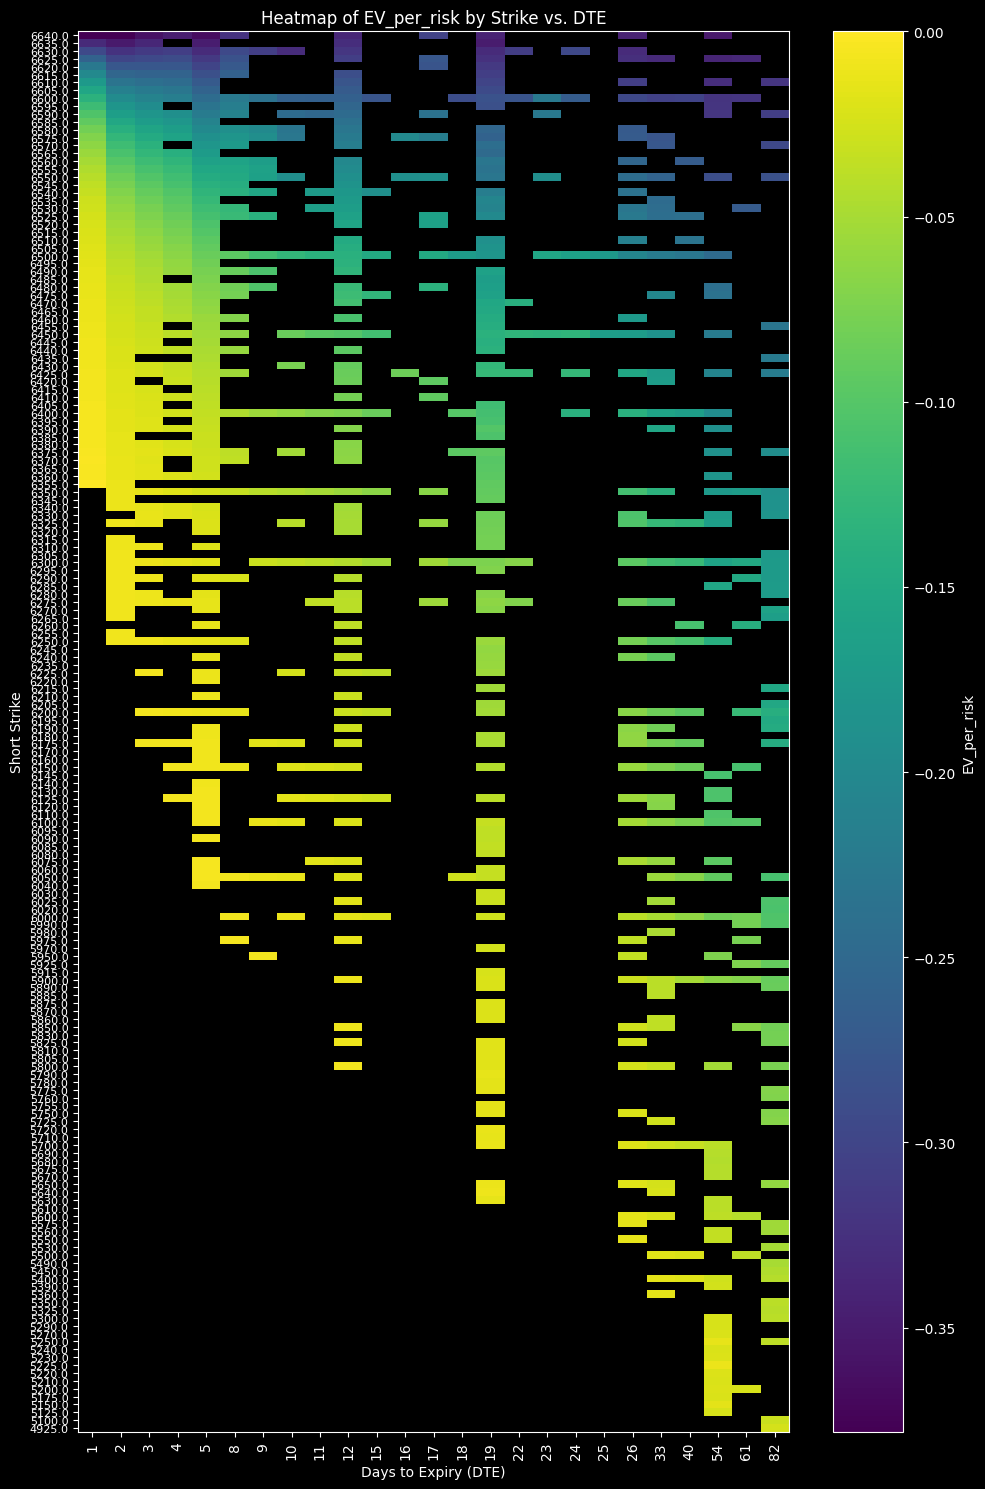

In [9]:
# work on a copy
df_plot = spreads.copy()

# build pivot (rows = short strike, cols = DTE)
pivot = df_plot.pivot_table(
    index='short_strike',
    columns='DTE',
    values='EV_per_risk',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 15))
im = ax.imshow(pivot, aspect='auto', origin='lower')

ax.set_xlabel('Days to Expiry (DTE)')
ax.set_ylabel('Short Strike')
ax.set_title('Heatmap of EV_per_risk by Strike vs. DTE')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)   # ← smaller font size

# or equivalently:
# ax.tick_params(axis='y', labelsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('EV_per_risk')

plt.tight_layout()
plt.show()